In [1]:
import uuid
import os
import re
import io
import argparse
import torch
import numpy as np
from PIL import Image

from tool_server.utils.utils import *
from tool_server.utils.server_utils import *
import matplotlib.pyplot as plt

from tool_server.tool_workers.online_workers.base_tool_worker import BaseToolWorker

from transformers import AutoModelForCausalLM, AutoProcessor, GenerationConfig, BitsAndBytesConfig

import gymnasium as gym
import re
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
from PIL import Image, ImageDraw

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
2025-07-17 16:49:40 | INFO | accelerate.utils.modeling | We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).
2025-07-17 16:50:24 | ERROR | stderr | /tmp/ipykernel_211803/2944994131.py:2: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
2025-07-17 16:50:24 | ERROR | stderr |   with torch.cuda.amp.autocast(dtype=torch.bfloat16):
2025-07-17 17:00:34 | ERROR | stderr | /tmp/ipykernel_211803/2944994131.py:2: FutureWarning: `torch.cuda.amp.autocast(args...)` is depreca

In [15]:
def extract_points( molmo_output, image_w, image_h):
    all_points = []
    for match in re.finditer(r'x\d*="\s*([0-9]+(?:\.[0-9]+)?)"\s+y\d*="\s*([0-9]+(?:\.[0-9]+)?)"', molmo_output):
        try:
            point = [float(match.group(i)) for i in range(1, 3)]
        except ValueError:
            pass
        else:
            point = np.array(point)
            if np.max(point) > 100:
                # Treat as an invalid output
                continue
            point /= 100.0
            point = point * np.array([image_w, image_h])
            all_points.append(point)
    return np.array(all_points)  # Ensure it's always a NumPy array
    
def create_image_with_points(image, coords, labels, marker_size=375):
    fig, ax = plt.subplots(figsize=(image.width / 100, image.height / 100), dpi=100)
    ax.imshow(image)
    # 修复image.format为None的情况
    image_format = 'png'  # 默认使用png格式
    if image.format is not None:
        image_format = image.format.lower()
        if image_format not in ['png', 'jpeg', 'jpg']:
            image_format = 'png'

    # Only show points if there are any valid coordinates
    show_points(coords, labels, ax, marker_size)

    plt.axis('off')  # Turn off axis

    # Convert the figure to a PIL image
    buf = BytesIO()
    plt.savefig(buf, format=image_format, bbox_inches='tight', pad_inches=0, transparent=True)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf)

def show_points(coords, labels, ax, marker_size=375):
    # Only plot if there are points
    if len(coords) == 0:
        return
    
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    
    if len(pos_points) > 0:
        ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    if len(neg_points) > 0:
        ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

In [2]:
# load the processor
model_path = "/mnt/petrelfs/songmingyang/songmingyang/model/mm/tools/Molmo-7B-D-0924"
processor = AutoProcessor.from_pretrained(
    model_path,
    trust_remote_code=True,
    torch_dtype='auto',
    device_map='auto'
)

# load the model
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    trust_remote_code=True,
    torch_dtype='auto',
    device_map='auto'
)


Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

In [39]:
image_path = "./frozenlake.png"
image = Image.open(image_path).convert("RGB")
text_prompt = "Point to the {} in the scene.".format("target")

inputs = processor.process(
    images=[image],
    text=text_prompt,
)
inputs["images"] = inputs["images"].to(torch.bfloat16)
inputs = {k: v.to(model.device).unsqueeze(0) for k, v in inputs.items()}

In [40]:

with torch.no_grad():
    with torch.cuda.amp.autocast(dtype=torch.bfloat16):

        output = model.generate_from_batch(
            inputs,
            GenerationConfig(max_new_tokens=1024, stop_strings="<|endoftext|>"),
            tokenizer=processor.tokenizer
        )

        # only get generated tokens; decode them to text
        generated_tokens = output[0,inputs['input_ids'].size(1):]
        response = processor.tokenizer.decode(generated_tokens, skip_special_tokens=True)


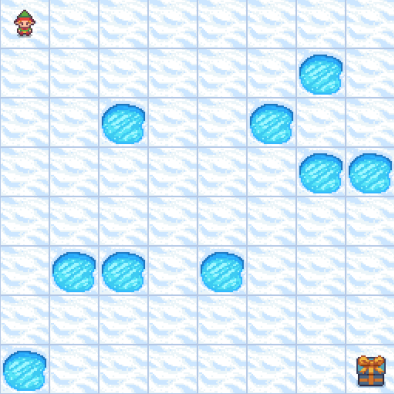

In [41]:

points = extract_points(response,image.width,image.height)

labels = np.ones(len(points), dtype=np.int32)
edited_image = create_image_with_points(image,points,labels)
edited_image

In [37]:
response

' There are none.'

In [38]:
points

array([], dtype=float64)